# Linear Regression

In [ ]:
'''
- y=mX + C

y -> Predict Data
m -> Slope / Coefficient [Each feature value has different slope]
X -> Data Point
C -> intercept [Constant]
'''

# Real State House Price Prediction using Regression Models

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Linear Regression Model
from sklearn.linear_model import LinearRegression
# Train Test Split
from sklearn.model_selection import train_test_split
# Feature Scaling
from sklearn.preprocessing import StandardScaler
# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('Dataset/Real estate.csv')
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


## Data Cleaning

In [3]:
# Remove unwanted columns
df = df.drop(columns = ['No', 'X1 transaction date'])

In [5]:
df.isnull().sum()

X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 6 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X2 house age                            414 non-null    float64
 1   X3 distance to the nearest MRT station  414 non-null    float64
 2   X4 number of convenience stores         414 non-null    int64  
 3   X5 latitude                             414 non-null    float64
 4   X6 longitude                            414 non-null    float64
 5   Y house price of unit area              414 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 19.5 KB


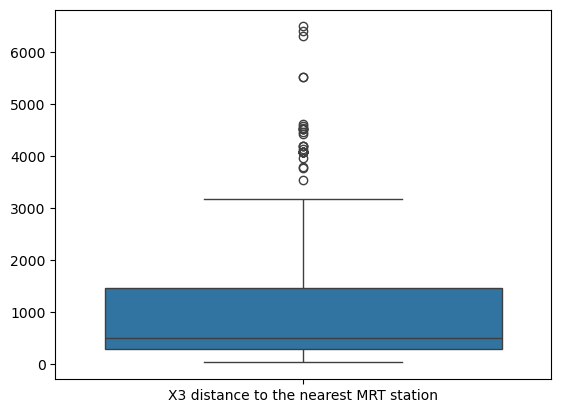

In [9]:
## Box Plot for detecting outliers
sns.boxplot(df[['X3 distance to the nearest MRT station']])
plt.show()

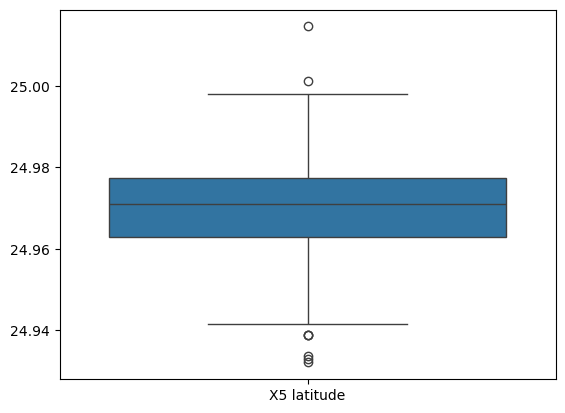

In [13]:
sns.boxplot(df[['X5 latitude']])
plt.show()

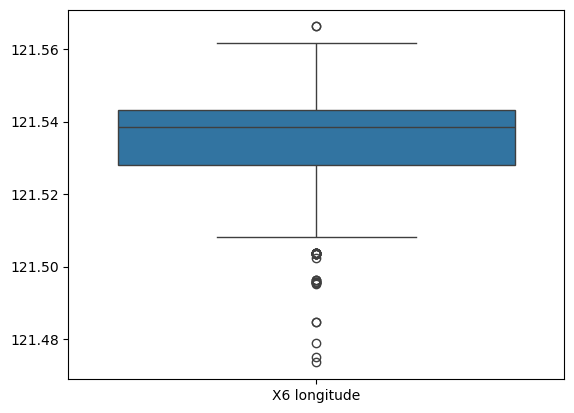

In [14]:
sns.boxplot(df[['X6 longitude']])
plt.show()

## Feature and Target

In [16]:
feature = ['X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 
           'X5 latitude', 'X6 longitude']
target = 'Y house price of unit area'

In [17]:
X = df[feature]
Y = df[target]

## Train Test Split

In [28]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

## Feature Scaling

In [ ]:
'''
    (Xi - Mean) / SD
    
    Feature Training -> fit_transform()
        - Fit -> Learning -> Calculates Mean and SD
        - Transform -> Implement -> Implements Formula into data
    
    
    Feature Testing -> transform()
        - Transform -> Implement -> Implements Training Learning data
'''

In [29]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

## Model Implementation

In [33]:
model = LinearRegression()
# Train model
model.fit(X_train_scale, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
Y_pred = model.predict(X_test_scale)

## Calculate Intercept and Slope/Coefficient of Model

In [37]:
beta_0 = model.intercept_
beta_1 = model.coef_

print(f'Intercept (Beta 0): {beta_0}')
print(f'Coefficient / Slope (Beta 1): {beta_1}')

Intercept (Beta 0): 38.39154078549814
Coefficient / Slope (Beta 1): [-3.06045213 -5.53623761  3.25926406  2.94298597 -0.35743672]


## Metrics

In [ ]:
'''
- Y_test -> Actual Data (X-axis)
- Y_pred -> Predicted Data (Y-axis)
'''

In [38]:
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE / Loss Function): {rmse}')
print(f'R2 Score (Residual Score / Cost Function): {r2}')

Mean Absolute Error (MAE): 5.350138374356212
Mean Squared Error (MSE): 54.580945200862146
Root Mean Squared Error (RMSE / Loss Function): 7.3878917967754605
R2 Score (Residual Score / Cost Function): 0.6746481382828176


## Visualization

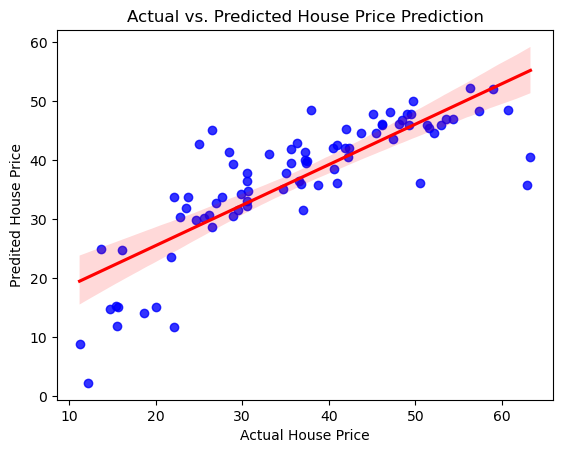

In [42]:
# regression plot
sns.regplot(x=Y_test, y=Y_pred, color='blue', line_kws={'color': 'red'})
plt.xlabel('Actual House Price')
plt.ylabel('Predited House Price')
plt.title('Actual vs. Predicted House Price Prediction')
plt.show()